In [1]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import torch
import diffusers

import sde_lib
import dnnlib
import solver_lib

torch.manual_seed(0)

C:\Users\ellak\Documents\deep_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with dnnlib.util.open_url("https://nvlabs-fi-cdn.nvidia.com/edm2/posthoc-reconstructions/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [3]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [5]:
labels = torch.eye(model.label_dim, device="cuda")[torch.randint(high=model.label_dim, size=(16,), device="cuda")]

In [6]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde_lib.EDMSDE().to("cuda")
rsde = sde_.get_reverse_sde(model, ode_threshold=0.2).to("cuda")
rsde.ode = False

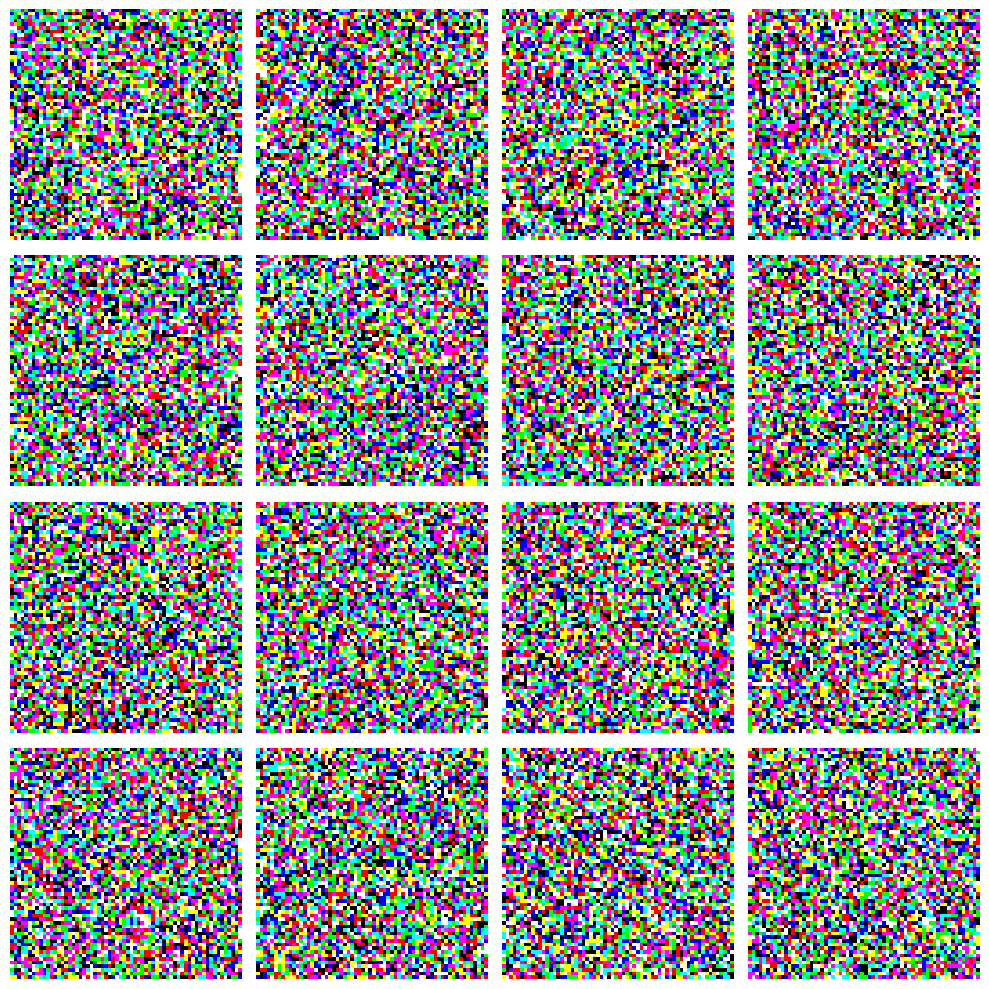

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [17]:
n_steps = 50
rho = 7
# From EDM2 code
discretisation = solver_lib.get_edm_schedule(n_steps, sigma_min, sigma_max, rho)

In [18]:
rsde.reset()

em_solver = solver_lib.HeunSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

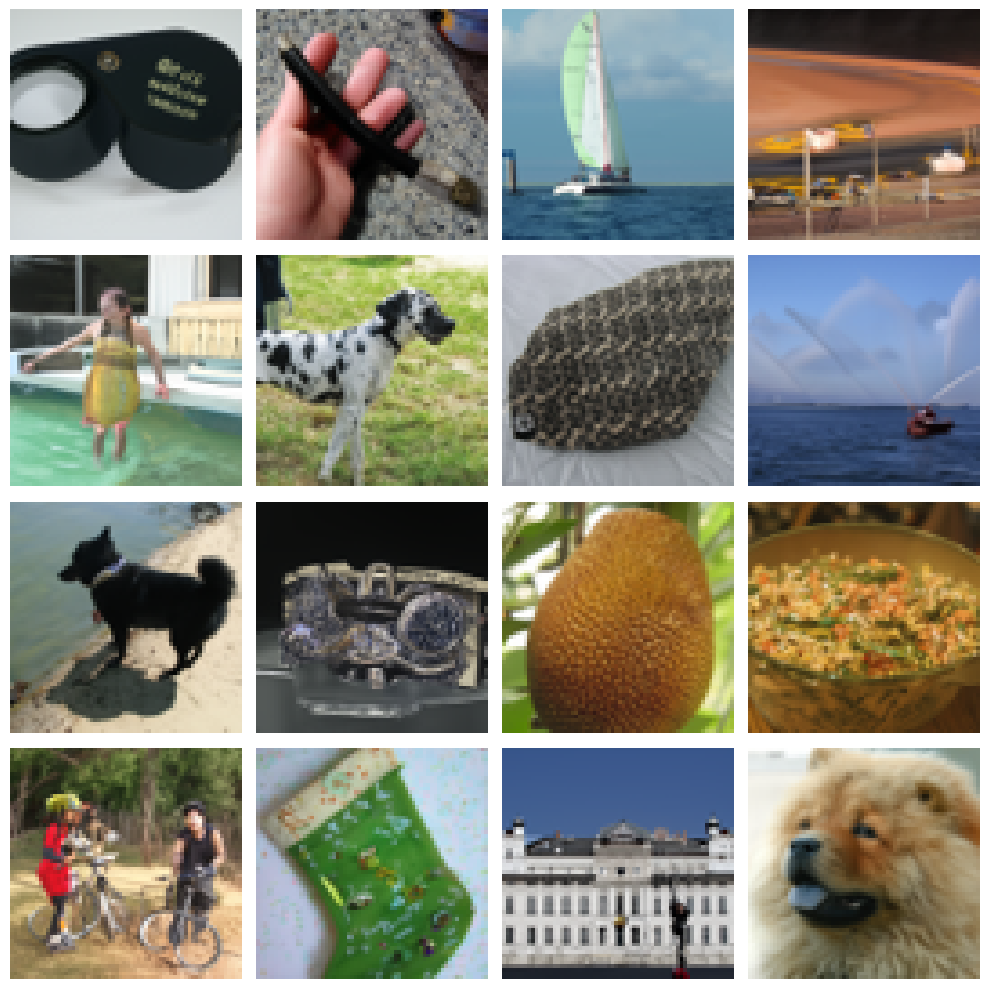

In [19]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [8]:
sigmas = []
sigmas_std = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())

In [25]:
sigmas = [80]
sigmas_std = [0]

rsde.reset()

pi_solver = solver_lib.PISolver(
    rsde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.289,
    tau_r=1.95,
    alpha=0.9,
    h_start=12,
    max_decrease=0.05,
    max_increase=2,
    interval=(80, 0),
    abs_error=False
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 68.0 h = -8.580256462097168 error = 0.708474338054657
sigma = 59.41974639892578 h = -7.19309139251709 error = 0.5192832946777344
sigma = 52.226654052734375 h = -6.02467155456543 error = 0.4815773069858551
sigma = 46.20198059082031 h = -5.174653053283691 error = 0.44377753138542175
sigma = 41.02732849121094 h = -4.511341094970703 error = 0.41888490319252014
sigma = 36.515987396240234 h = -3.957700252532959 error = 0.40647971630096436
sigma = 32.55828857421875 h = -3.4965617656707764 error = 0.39639830589294434
sigma = 29.061725616455078 h = -3.09700870513916 error = 0.3914169669151306
sigma = 25.96471405029297 h = -2.7608985900878906 error = 0.38393884897232056
sigma = 23.20381736755371 h = -2.4592628479003906 error = 0.3828648030757904
sigma = 20.744552612304688 h = -2.193289279937744 error = 0.38141676783561707
sigma = 18.5512638092041 h = -1.9580856561660767 error = 0.38009464740753174
sigma = 16.593177795410156 h = -1.7526013851165771 error = 0.37731412053108215
sigma = 14.8

In [26]:
rsde.nfe / 16

99.5

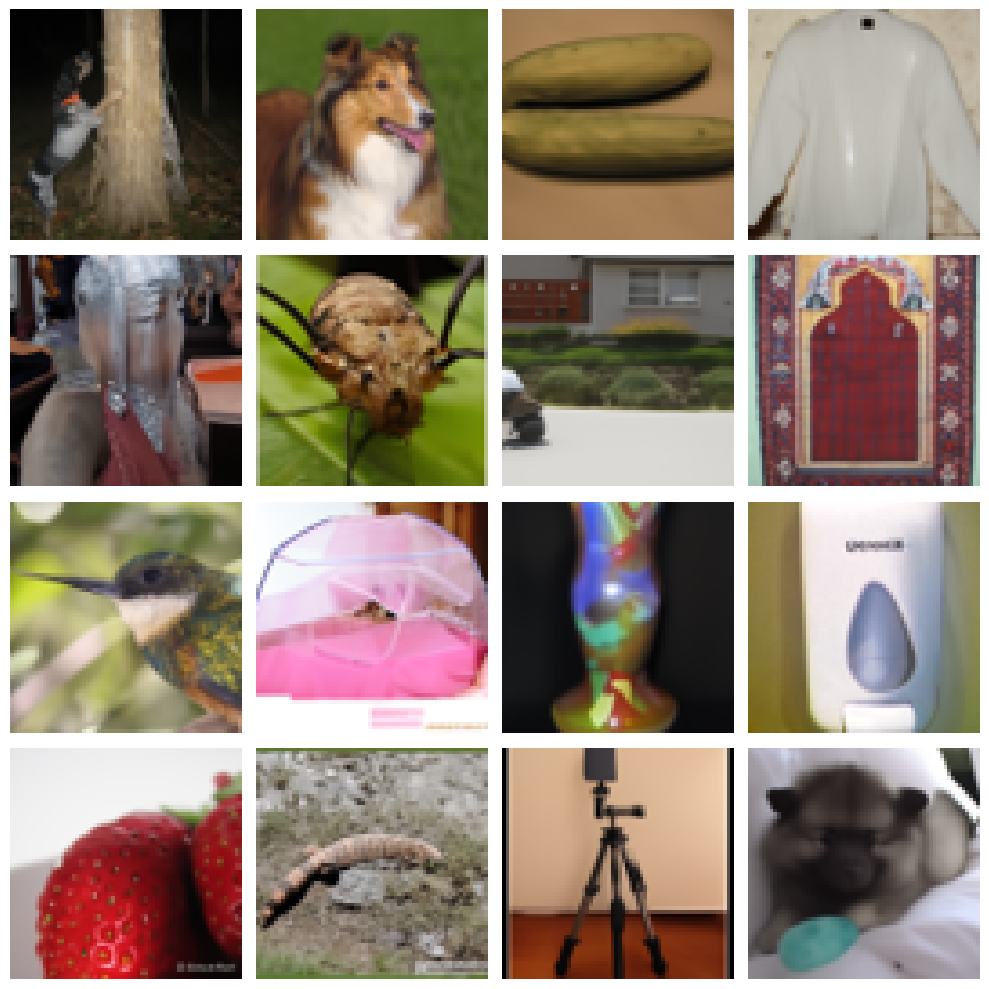

In [27]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

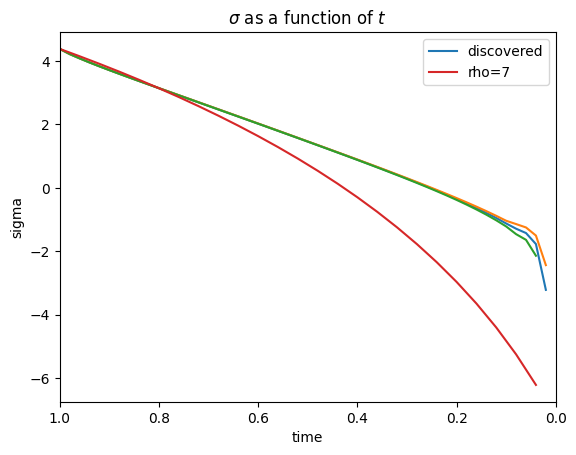

In [34]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas)), label="discovered")

plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) + torch.tensor(sigmas_std)))
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) - torch.tensor(sigmas_std)))
plt.plot(torch.linspace(1, 0, len(discretisation)), torch.log(discretisation.cpu()), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")

In [26]:
x_edm = solver_lib.edm_sampler(model, noise.clone() / 80, labels, num_steps=n_steps // 2)

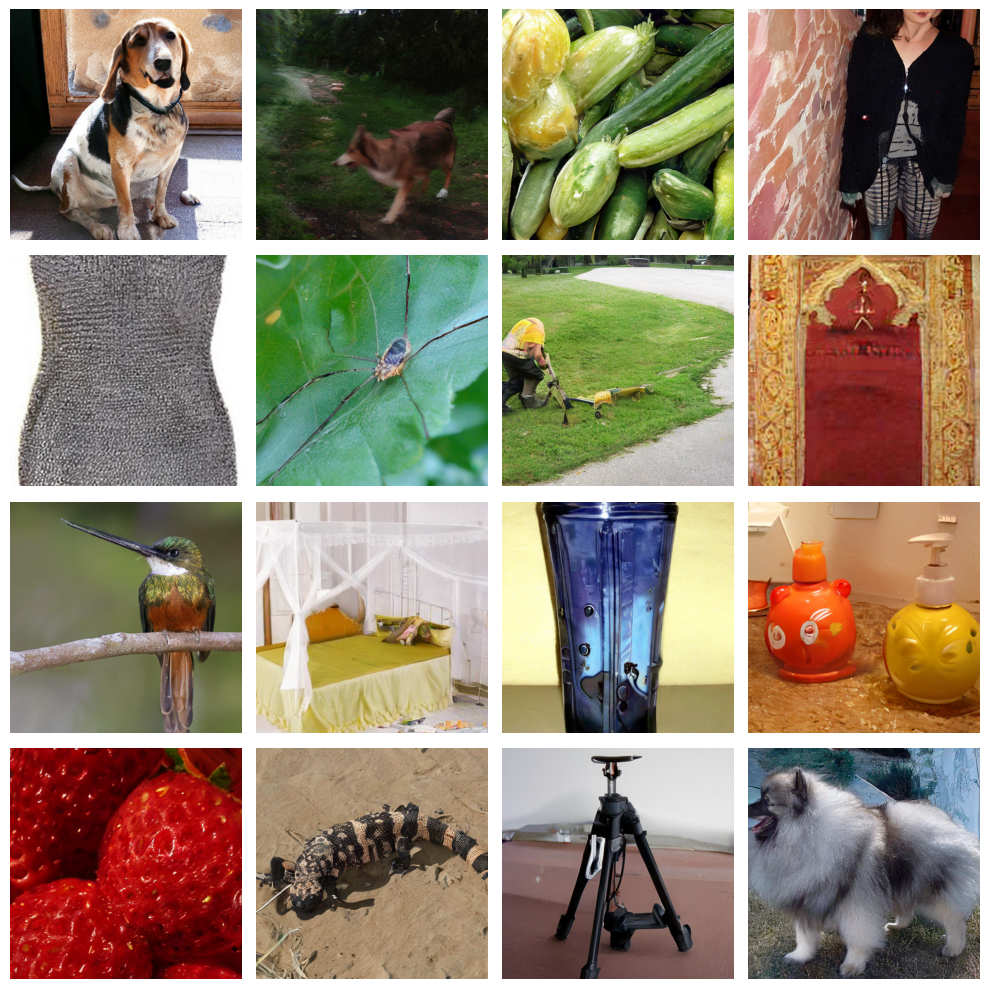

In [27]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())